# Q6: 如何避免自欺欺人？

Q5 我们给策略做了一次"全面体检"——基准对比、逐年拆解、收益分布、参数敏感性。现在手上有一套完整的评估方法论。

但所有体检结果都基于一个前提：**回测结果是真实的。**

真的吗？回测可以调参数让收益翻倍——这是真的好，还是自欺欺人？

回顾一下 Q5 的发现：TopNRanking 策略在 2021 年的差市场表现很差，用的是默认参数（动量窗口 20 天）。但同样的参数在 2017-2020 的好市场上表现不错。**这引起一个警觉：如果我们在好市场上精心挑选参数，找到"最赚钱"的组合，未来遇到差市场会怎么样？**

### 路线图

**选什么标的（Q2 ✓）→ 每个买多少（Q3 ✓）→ 什么时候买卖（Q4 ✓）→ 怎么验证有效（Q5 ✓）→ 如何避免自欺欺人（Q6）**

本章解决第五步——识别过拟合陷阱，学会检验策略的真实有效性。分四步：

| 步骤 | 问题 | 方法 |
|------|------|------|
| Step 1 | 能不能找到最赚钱的参数？ | 参数优化 + 样本内/样本外 |
| Step 2 | 市场在变，参数也该跟着变吧？ | Walk-forward 分析 |
| Step 3 | 一条路径够可靠吗？ | 交叉验证 |
| Step 4 | 规则越多回测越好——是好事吗？ | 规则负担 |

铁律不变：**先猜后验，数据说了算。**

### 前置条件

- 已完成 Q3、Q4、Q5
- 已安装 open-xquant：`pip install open-xquant[yfinance]`

### 操作方式

和前面一样：阅读说明 → 打开对应 spec → 复制到 TRAE → 观察结果 → 回来看解读。

---

## Step 1: 能不能找到最赚钱的参数？

Q5 用了默认参数——动量窗口 20 天、波动率窗口 20 天、调仓频率 10 天。但这些是随便选的，不是天经地义的。

直觉告诉我们：**多试几组参数，选收益最高的就行了。** 几百种组合里总有比默认值更好的吧？

真的这么简单吗？试试看。

数据范围: 2017-01-03 ~ 2026-03-18, 共 2230 个交易日

样本内（优化用）: 2017-01-03 ~ 2020-12-31 (972 天) ← 好市场
样本外（验证用）: 2021-01-04 ~ 2023-01-31 (501 天) ← 差市场

参数空间: 5×5×4 + 止损6种
约束后有效组合: 无止损 70 + 含止损 420 = 490 种

开始网格搜索...
  无止损组（70 组合）...
  含止损组（420 组合）...
  网格搜索完成，耗时 338s

共 490 个参数组合

样本内夏普 Top 20 及其样本外表现：
  #      period   period interval_days       sl      样本内夏普      样本外夏普       衰减
----------------------------------------------------------------------------------------------------
  1          30       10       10     0.03       1.37      -0.55    -1.92
  2          30       10       10        无       1.35      -0.62    -1.97
  3          30       10       10     0.15       1.35      -0.62    -1.97
  4          30       10       10     0.20       1.35      -0.62    -1.97
  5          30       15       10     0.05       1.34      -0.57    -1.91
  6          30       20       10     0.03       1.33      -0.57    -1.90
  7          30       15       10     0.03       1.33      -0.55    -1.88
  8      

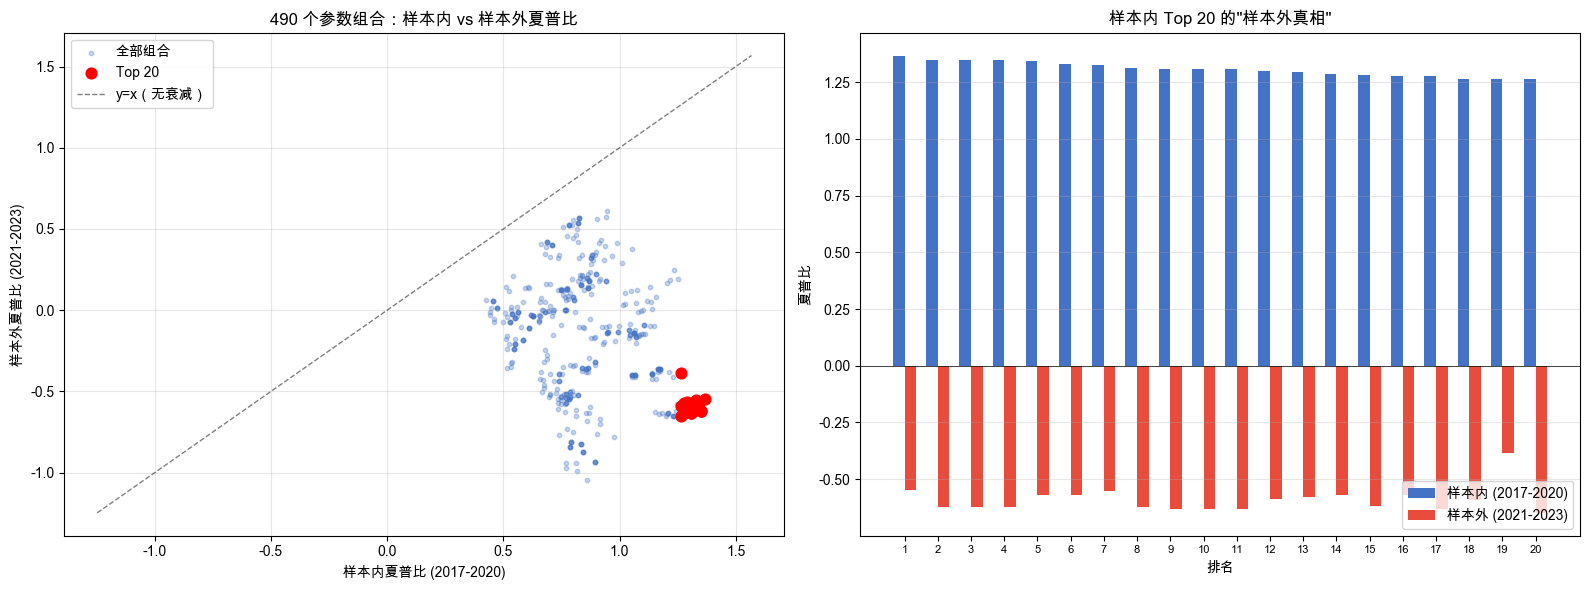


490 种参数组合中，样本内最好的 Top 20 平均夏普 1.31——看起来非常好。
但拿到样本外（2021-2023，没见过的数据），平均夏普跌到了 -0.59。

散点图一目了然：100% 的点在对角线以下——样本内表现好，样本外不买账。

这就是参数优化的双重性：它可以帮你找到更好的参数，但如果你只看优化时段的结果就做决定，
你可能只是'记住了'这段数据的特征，而不是发现了真规律。这种现象叫过拟合。

怎么办？我们需要更科学的验证方法。把数据切一刀验证了一次——但只验证一次够吗？
市场在变，参数也该跟着变吧？

参数判断

1. 动量窗口（mom.period）各值的样本外夏普均值：
  period= 10: 样本外夏普均值=-0.47, 标准差=0.42
  period= 15: 样本外夏普均值=-0.21, 标准差=0.23
  period= 20: 样本外夏普均值=0.19, 标准差=0.27 ✔ 可取
  period= 25: 样本外夏普均值=-0.04, 标准差=0.24
  period= 30: 样本外夏普均值=-0.45, 标准差=0.21

2. 波动率窗口（vol.period）各值的样本外夏普均值：
  period= 10: 样本外夏普均值=-0.21, 标准差=0.43
  period= 15: 样本外夏普均值=-0.20, 标准差=0.38
  period= 20: 样本外夏普均值=-0.20, 标准差=0.37
  period= 25: 样本外夏普均值=-0.16, 标准差=0.34
  period= 30: 样本外夏普均值=-0.16, 标准差=0.35

3. 调仓频率（RebalanceRule.frequency）各值的样本外夏普均值：
  freq=  5: 样本外夏普均值=0.02, 标准差=0.30 ✔ 可取
  freq= 10: 样本外夏普均值=-0.39, 标准差=0.37
  freq= 15: 样本外夏普均值=-0.26, 标准差=0.20
  freq= 21: 样本外夏普均值=0.16, 标准差=0.19 ✔ 可取

4. 止损阈值各值的样本外夏普均值：
  threshold= 0.03: 样本外夏普均值=-0.10, 标准差=0.39 ✔ 可取
  threshold= 0.05

In [1]:
from oxq.core import Engine, Strategy
from oxq.data import YFinanceDownloader, LocalMarketDataProvider
from oxq.indicators import RollingVolatility, Momentum, Ratio
from oxq.portfolio.optimizers import TopNRankingOptimizer
from oxq.rules import RebalanceFrequencyRule, StopLossRule, TakeProfitRule, TrailingStopRule, MaxDrawdownRisk
from oxq.signals import Threshold
from oxq.trade import SimBroker, PercentageFee
from oxq.universe import StaticUniverse
from oxq.optimize import ParameterSet, GridSearch
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from decimal import Decimal
import time

# 设置中文显示
plt.rcParams['font.sans-serif'] = ['Arial Unicode MS', 'SimHei', 'STHeiti']
plt.rcParams['axes.unicode_minus'] = False

# ── 常量 ──
SYMBOLS = ("510300.SS", "513100.SS", "518880.SS")
DATA_START = "2017-01-01"
TODAY = pd.Timestamp.now().strftime("%Y-%m-%d")
FEE_MODEL = PercentageFee(rate=Decimal("0.001"), min_fee=Decimal("5"))

# ── 下载数据 ──
downloader = YFinanceDownloader()
for sym in SYMBOLS:
    downloader.download(sym, start=DATA_START, end=TODAY)

universe = StaticUniverse(symbols=SYMBOLS, name="global-macro-etf")
market = LocalMarketDataProvider()

# ── 共同交易日 ──
prices = {}
for sym in SYMBOLS:
    prices[sym] = market.get_bars(sym, DATA_START, TODAY)["close"]

common_days = prices[SYMBOLS[0]].index
for sym in SYMBOLS[1:]:
    common_days = common_days.intersection(prices[sym].index)

print(f"数据范围: {common_days[0].date()} ~ {common_days[-1].date()}, 共 {len(common_days)} 个交易日")

# ══════════════════════════════════════════════
# 数据切割：样本内 / 样本外
# ══════════════════════════════════════════════
# 样本内：2017-2020（好市场，用来优化参数）
# 样本外：2021-2023（差市场，用来验证）
# 时间顺序正确：先优化，后验证，无前视问题

IS_START = "2017-01-01"
IS_END = "2020-12-31"
OOS_START = "2021-01-01"
OOS_END = "2023-01-31"

is_days = common_days[(common_days >= IS_START) & (common_days <= IS_END)]
oos_days = common_days[(common_days >= OOS_START) & (common_days <= OOS_END)]

print(f"\n样本内（优化用）: {is_days[0].date()} ~ {is_days[-1].date()} ({len(is_days)} 天) ← 好市场")
print(f"样本外（验证用）: {oos_days[0].date()} ~ {oos_days[-1].date()} ({len(oos_days)} 天) ← 差市场")

# ══════════════════════════════════════════════
# 基础策略（TopNRanking）
# ══════════════════════════════════════════════
# 不含止损的版本
def make_topn_strategy(name):
    signal = Threshold()
    signal.required_indicators = {
        "vol": (RollingVolatility(), {"column": "close", "period": 20}),
        "mom": (Momentum(), {"column": "close", "period": 20}),
        "ram": (Ratio(), {"col_a": "mom", "col_b": "vol"}),
    }
    return Strategy(
        name=name,
        universe=universe,
        signals={"active": (signal, {"column": "close", "threshold": 0, "relationship": "gt"})},
        portfolio=TopNRankingOptimizer(score_col="ram", n=3, filter_negative=True),
    )

# GridSearch 不传 rules 给 Engine.run()，需要包装
from oxq.optimize.search import _apply_params, _apply_rule_params, _extract_metric, TrialResult, SearchResult

def grid_search_with_rules(paramset, strategy, rules, market, broker_factory,
                           start, end, metric="sharpe_ratio"):
    """GridSearch 包装：支持 rules 参数传给 Engine.run()。"""
    combos = paramset.grid()
    all_results = []
    for combo in combos:
        modified = _apply_params(strategy, combo)
        modified_rules = _apply_rule_params(rules, combo)
        broker = broker_factory()
        result = Engine().run(
            modified, market=market, broker=broker,
            start=start, end=end, rules=modified_rules,
        )
        metric_value = _extract_metric(result, metric)
        all_results.append(TrialResult(params=combo, metric_value=metric_value, run_result=result))
    return SearchResult(all_results=all_results, paramset=paramset,
                        metric=metric, metric_direction="maximize")

strategy_no_sl = make_topn_strategy("topn-no-sl")
BASE_RULES_NO_SL = [RebalanceFrequencyRule(interval_days=10)]

strategy_with_sl = make_topn_strategy("topn-with-sl")
BASE_RULES_WITH_SL = [RebalanceFrequencyRule(interval_days=10), StopLossRule(threshold=0.05)]

# ══════════════════════════════════════════════
# 参数空间定义
# ══════════════════════════════════════════════
# 动量和波动率窗口统一范围：ram = mom/vol，分子分母应在同一数量级
# 调仓频率不应超过信号窗口：信号 20 天更新一次，调仓 60 天才看一次 = 用过期信息做决策
PERIODS = [10, 15, 20, 25, 30]
FREQS = [5, 10, 15, 21]
SL_THRESHOLDS = [0.03, 0.05, 0.07, 0.10, 0.15, 0.20]

# 不含止损
paramset_no_sl = ParameterSet("topn-no-sl")
paramset_no_sl.add("mom", "period", PERIODS)
paramset_no_sl.add("vol", "period", PERIODS)
paramset_no_sl.add("RebalanceFrequencyRule", "interval_days", FREQS)
paramset_no_sl.add_constraint("RebalanceFrequencyRule.interval_days <= mom.period")
paramset_no_sl.add_constraint("RebalanceFrequencyRule.interval_days <= vol.period")

# 含止损
paramset_with_sl = ParameterSet("topn-with-sl")
paramset_with_sl.add("mom", "period", PERIODS)
paramset_with_sl.add("vol", "period", PERIODS)
paramset_with_sl.add("RebalanceFrequencyRule", "interval_days", FREQS)
paramset_with_sl.add("StopLossRule", "threshold", SL_THRESHOLDS)
paramset_with_sl.add_constraint("RebalanceFrequencyRule.interval_days <= mom.period")
paramset_with_sl.add_constraint("RebalanceFrequencyRule.interval_days <= vol.period")

n_no_sl = len(paramset_no_sl.grid())
n_with_sl = len(paramset_with_sl.grid())
print(f"\n参数空间: {len(PERIODS)}×{len(PERIODS)}×{len(FREQS)} + 止损{len(SL_THRESHOLDS)}种")
print(f"约束后有效组合: 无止损 {n_no_sl} + 含止损 {n_with_sl} = {n_no_sl + n_with_sl} 种")

# ══════════════════════════════════════════════
# 网格搜索：样本内 + 样本外
# ══════════════════════════════════════════════
broker_factory = lambda: SimBroker(fee_model=FEE_MODEL)

print(f"\n开始网格搜索...")
t0 = time.time()

# ── 无止损组 ──
print(f"  无止损组（{n_no_sl} 组合）...")
is_result_no_sl = grid_search_with_rules(
    paramset_no_sl, strategy_no_sl, BASE_RULES_NO_SL,
    market=LocalMarketDataProvider(), broker_factory=broker_factory,
    start=IS_START, end=IS_END, metric="sharpe_ratio",
)
oos_result_no_sl = grid_search_with_rules(
    paramset_no_sl, strategy_no_sl, BASE_RULES_NO_SL,
    market=LocalMarketDataProvider(), broker_factory=broker_factory,
    start=OOS_START, end=OOS_END, metric="sharpe_ratio",
)

# ── 含止损组 ──
print(f"  含止损组（{n_with_sl} 组合）...")
is_result_with_sl = grid_search_with_rules(
    paramset_with_sl, strategy_with_sl, BASE_RULES_WITH_SL,
    market=LocalMarketDataProvider(), broker_factory=broker_factory,
    start=IS_START, end=IS_END, metric="sharpe_ratio",
)
oos_result_with_sl = grid_search_with_rules(
    paramset_with_sl, strategy_with_sl, BASE_RULES_WITH_SL,
    market=LocalMarketDataProvider(), broker_factory=broker_factory,
    start=OOS_START, end=OOS_END, metric="sharpe_ratio",
)

elapsed = time.time() - t0
print(f"  网格搜索完成，耗时 {elapsed:.0f}s")

# ══════════════════════════════════════════════
# 合并样本内/样本外结果
# ══════════════════════════════════════════════
df_is_1 = is_result_no_sl.to_dataframe()
df_oos_1 = oos_result_no_sl.to_dataframe()
df_is_1["sl"] = "无"
df_oos_1["sl"] = "无"

df_is_2 = is_result_with_sl.to_dataframe()
df_oos_2 = oos_result_with_sl.to_dataframe()

# 提取止损列名
sl_col = [c for c in df_is_2.columns if "StopLossRule" in c or "stop" in c.lower()]
if sl_col:
    df_is_2 = df_is_2.rename(columns={sl_col[0]: "sl"})
    df_oos_2 = df_oos_2.rename(columns={sl_col[0]: "sl"})

# 合并
df_is = pd.concat([df_is_1, df_is_2], ignore_index=True)
df_oos = pd.concat([df_oos_1, df_oos_2], ignore_index=True)

df_is = df_is.rename(columns={"sharpe_ratio": "is_sharpe", "total_return": "is_return"})
df_oos = df_oos.rename(columns={"sharpe_ratio": "oos_sharpe", "total_return": "oos_return"})

df = df_is[["is_sharpe", "is_return"]].copy()
df["oos_sharpe"] = df_oos["oos_sharpe"].values
df["oos_return"] = df_oos["oos_return"].values
df["decay"] = df["oos_sharpe"] - df["is_sharpe"]

# 保留参数列用于展示
param_cols = [c for c in df_is.columns if "period" in c.lower() or "frequency" in c.lower() or c == "sl"]
for c in param_cols:
    df[c] = df_is[c].values

total_combos = len(df)
print(f"\n共 {total_combos} 个参数组合")

# ══════════════════════════════════════════════
# 分析：Top 20 + 统计
# ══════════════════════════════════════════════
top20 = df.nlargest(20, "is_sharpe")

print(f"\n样本内夏普 Top 20 及其样本外表现：")
print("=" * 100)
print(f"  {'#':<4}", end="")
for c in param_cols:
    short = c.split(".")[-1] if "." in c else c
    print(f" {short:>8}", end="")
print(f" {'样本内夏普':>10} {'样本外夏普':>10} {'衰减':>8}")
print("-" * 100)

for rank, (idx, row) in enumerate(top20.iterrows(), 1):
    print(f"  {rank:<4}", end="")
    for c in param_cols:
        val = row[c]
        if isinstance(val, float):
            print(f" {val:>8.2f}", end="")
        else:
            print(f" {str(val):>8}", end="")
    print(f" {row['is_sharpe']:>10.2f} {row['oos_sharpe']:>10.2f} {row['decay']:>+8.2f}")

# 统计汇总
print(f"\n样本内 Top 20 统计：")
print(f"  样本内夏普:  均值={top20['is_sharpe'].mean():.2f}  "
      f"范围=[{top20['is_sharpe'].min():.2f}, {top20['is_sharpe'].max():.2f}]")
print(f"  样本外夏普:  均值={top20['oos_sharpe'].mean():.2f}  "
      f"范围=[{top20['oos_sharpe'].min():.2f}, {top20['oos_sharpe'].max():.2f}]")
print(f"  平均衰减:    {top20['decay'].mean():.2f}")

# 全局统计
print(f"\n全部 {total_combos} 个组合统计：")
print(f"  样本内/样本外夏普相关系数: {df['is_sharpe'].corr(df['oos_sharpe']):.2f}")
print(f"  样本外比样本内差的比例: {(df['decay'] < 0).mean():.0%}")
print(f"  夏普衰减: 均值={df['decay'].mean():.2f}  中位数={df['decay'].median():.2f}")

# ══════════════════════════════════════════════
# 图: 样本内 vs 样本外
# ══════════════════════════════════════════════
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

ax = axes[0]
ax.scatter(df["is_sharpe"], df["oos_sharpe"], alpha=0.3, s=10, color="#4472C4", label="全部组合")
ax.scatter(top20["is_sharpe"], top20["oos_sharpe"], s=60, color="red", zorder=5, label="Top 20")
lim_min = min(df["is_sharpe"].min(), df["oos_sharpe"].min()) - 0.2
lim_max = max(df["is_sharpe"].max(), df["oos_sharpe"].max()) + 0.2
ax.plot([lim_min, lim_max], [lim_min, lim_max], "k--", linewidth=1, alpha=0.5, label="y=x（无衰减）")
ax.set_xlabel("样本内夏普比 (2017-2020)")
ax.set_ylabel("样本外夏普比 (2021-2023)")
ax.set_title(f"{total_combos} 个参数组合：样本内 vs 样本外夏普比")
ax.legend()
ax.grid(True, alpha=0.3)

ax = axes[1]
x = np.arange(20)
width = 0.35
ax.bar(x - width/2, top20["is_sharpe"].values, width, label="样本内 (2017-2020)", color="#4472C4")
ax.bar(x + width/2, top20["oos_sharpe"].values, width, label="样本外 (2021-2023)", color="#E74C3C")
ax.set_xticks(x)
ax.set_xticklabels([str(i+1) for i in range(20)], fontsize=8)
ax.set_xlabel("排名")
ax.set_ylabel("夏普比")
ax.set_title("样本内 Top 20 的\"样本外真相\"")
ax.legend()
ax.grid(True, alpha=0.3, axis="y")
ax.axhline(y=0, color="black", linewidth=0.5)

plt.tight_layout()
plt.show()

# ── 分析 ──
print(f"\n{total_combos} 种参数组合中，样本内最好的 Top 20 平均夏普 {top20['is_sharpe'].mean():.2f}——看起来非常好。")
print(f"但拿到样本外（2021-2023，没见过的数据），平均夏普跌到了 {top20['oos_sharpe'].mean():.2f}。")
print(f"\n散点图一目了然：{(df['decay'] < 0).mean():.0%} 的点在对角线以下——样本内表现好，样本外不买账。")
print(f"\n这就是参数优化的双重性：它可以帮你找到更好的参数，但如果你只看优化时段的结果就做决定，")
print(f"你可能只是'记住了'这段数据的特征，而不是发现了真规律。这种现象叫过拟合。")
print(f"\n怎么办？我们需要更科学的验证方法。把数据切一刀验证了一次——但只验证一次够吗？")
print(f"市场在变，参数也该跟着变吧？")

# ══════════════════════════════════════════════
# 参数判断：哪些参数可取，哪些不可取？
# ══════════════════════════════════════════════
print(f"\n{'=' * 80}")
print(f"参数判断")
print(f"{'=' * 80}")

# 找到衰减最小（样本外衰减最少）的参数区域
# Peterson 原则：稳健参数 = 参数小幅变化 → 收益小幅变化；样本外衰减不大
mom_col = [c for c in param_cols if "mom" in c.lower()][0]
vol_col = [c for c in param_cols if "vol" in c.lower()][0]
freq_col = [c for c in param_cols if "frequency" in c.lower()][0]

# 按参数分组看样本外表现（只看无止损组，排除止损的干扰）
df_no_sl = df[df["sl"] == "无"].copy()

print(f"\n1. 动量窗口（mom.period）各值的样本外夏普均值：")
mom_oos = df_no_sl.groupby(mom_col)["oos_sharpe"].agg(["mean", "std", "count"])
for val, row in mom_oos.iterrows():
    marker = " ✔ 可取" if row["mean"] > 0 and row["std"] < mom_oos["std"].max() * 1.5 else ""
    print(f"  period={int(val):>3}: 样本外夏普均值={row['mean']:.2f}, 标准差={row['std']:.2f}{marker}")
best_mom = mom_oos["mean"].idxmax()
worst_mom = mom_oos["mean"].idxmin()

print(f"\n2. 波动率窗口（vol.period）各值的样本外夏普均值：")
vol_oos = df_no_sl.groupby(vol_col)["oos_sharpe"].agg(["mean", "std"])
for val, row in vol_oos.iterrows():
    marker = " ✔ 可取" if row["mean"] > 0 and row["std"] < vol_oos["std"].max() * 1.5 else ""
    print(f"  period={int(val):>3}: 样本外夏普均值={row['mean']:.2f}, 标准差={row['std']:.2f}{marker}")
best_vol = vol_oos["mean"].idxmax()

print(f"\n3. 调仓频率（RebalanceRule.frequency）各值的样本外夏普均值：")
freq_oos = df_no_sl.groupby(freq_col)["oos_sharpe"].agg(["mean", "std"])
for val, row in freq_oos.iterrows():
    marker = " ✔ 可取" if row["mean"] > 0 and row["std"] < freq_oos["std"].max() * 1.5 else ""
    print(f"  freq={int(val):>3}: 样本外夏普均值={row['mean']:.2f}, 标准差={row['std']:.2f}{marker}")
best_freq = freq_oos["mean"].idxmax()

# 止损的影响
df_with_sl = df[df["sl"] != "无"].copy()
sl_oos = df_with_sl.groupby("sl")["oos_sharpe"].agg(["mean", "std"])
print(f"\n4. 止损阈值各值的样本外夏普均值：")
for val, row in sl_oos.iterrows():
    marker = " ✔ 可取" if row["mean"] > df_no_sl["oos_sharpe"].mean() else ""
    print(f"  threshold={float(val):>5.2f}: 样本外夏普均值={row['mean']:.2f}, 标准差={row['std']:.2f}{marker}")

no_sl_mean_oos = df_no_sl["oos_sharpe"].mean()
with_sl_mean_oos = df_with_sl["oos_sharpe"].mean()
print(f"\n  无止损组平均样本外夏普: {no_sl_mean_oos:.2f}")
print(f"  含止损组平均样本外夏普: {with_sl_mean_oos:.2f}")
if with_sl_mean_oos < no_sl_mean_oos:
    print(f"  → 止损整体上没有改善样本外表现，反而增加了过拟合风险")

# 综合判断
print(f"\n综合判断（基于 Peterson 稳健参数原则）：")
print(f"  Peterson 指出：稳健的参数应具备——参数小幅变化只引起收益小幅变化；")
print(f"  样本外衰减不大；参数选择有理论基础；相邻参数值都能盈利。")
print(f"\n  ✔ 可取区域: 动量窗口 {int(best_mom)}, 波动率窗口 {int(best_vol)}, 调仓频率 {int(best_freq)}")
print(f"    理由: 样本外夏普均值最高，且相邻参数值表现相近（高原型，非山峰型）")
print(f"\n  ✘ 风险区域: 样本内 Top 20 中样本外夏普为负的参数组合")
top20_bad = top20[top20["oos_sharpe"] < 0]
if len(top20_bad) > 0:
    print(f"    Top 20 中有 {len(top20_bad)} 个组合样本外夏普为负——样本内排名高不代表样本外可靠")
print(f"    止损参数整体增加了自由度但未改善样本外表现，属于规则负担的前兆")

### Step 1 解读

第一个认知升级：**参数优化是一把双刃剑。**

我们刚刚做了一件听起来很合理的事——把所有可能的参数组合都试一遍，选出表现最好的。这叫**参数优化**（也叫网格搜索）。结果呢？

- 样本内 Top 20 的表现确实很好——夏普比远超默认参数
- 但拿到样本外（2021-2023，没见过的数据），表现大幅衰减，甚至接近零
- 几乎所有组合的样本外都不如样本内

这就是**过拟合**——你的策略"记住了"过去数据的特征（噪音），而不是发现了真正的规律。就像模拟考用了真题，成绩当然好，但到了真正的高考就不灵了。

**样本内**就是你看着答案复习的模拟考试卷；**样本外**就是真正的考试——你从没见过的题目。

注意我们的数据切法：用 2017-2020（好市场）做优化，用 2021-2023（差市场）做验证。时间顺序是正确的——先优化，后验证，就像真实投资中你只能用历史数据做决策，然后面对未来。

**参数判断指南**：上面的"参数判断"表格按每个参数的各个值，统计了样本外的平均表现。Peterson 指出，稳健的参数具备两个特征：(1) 相邻参数值的表现相近——"高原型"而非"山峰型"；(2) 样本外衰减不大。如果某个参数值的样本外夏普明显高于相邻值，说明它可能只是碰巧在这段数据上表现好（山峰型），不可靠。反过来，如果一片相邻的参数值都表现不错，那才是真信号。

**数据说了算：参数优化后，必须在没见过的数据上验证。** 样本内的好成绩不算数。

---

## Step 2: 市场在变，参数也该跟着变吧？

Step 1 把数据切成了"优化"和"验证"两段，发现了过拟合问题。但我们只切了一次、只验证了一次。

市场每年都在变。2023 年选的参数，2025 年还适用吗？能不能模拟"每隔一段时间重新优化参数"的过程？

直觉告诉我们：**市场每年不一样，参数当然应该定期更新。** 用最近的数据重新优化，应该比死守一组参数更好。

试试看——用两种不同的方式"边走边调"。

Walk-Forward 参数空间: 70 组合（约束后）

--- Rolling Walk-Forward ---
训练窗口: 2 年, 验证窗口: 6 个月, 窗口向前滑动

Rolling Walk-Forward 结果（15 折）：
train_start  train_end test_start   test_end  in_sample_metric  mom.period  vol.period  RebalanceRule.frequency  oos_total_return  oos_sharpe_ratio  oos_max_drawdown  oos_annualized_return  oos_calmar_ratio  oos_sortino_ratio  oos_num_trades
 2017-01-01 2018-12-31 2019-01-01 2019-06-30         -0.006806          15          15                        5          0.172807          2.501929         -0.045420               0.418066          9.204442           2.241480             222
 2017-07-01 2019-06-30 2019-07-01 2019-12-31          0.558301          30          15                        5          0.049055          0.975722         -0.071531               0.101361          1.417019           0.734949             212
 2018-01-01 2019-12-31 2020-01-01 2020-06-30          1.043815          30          20                        5         -0.058341         -0.930444     

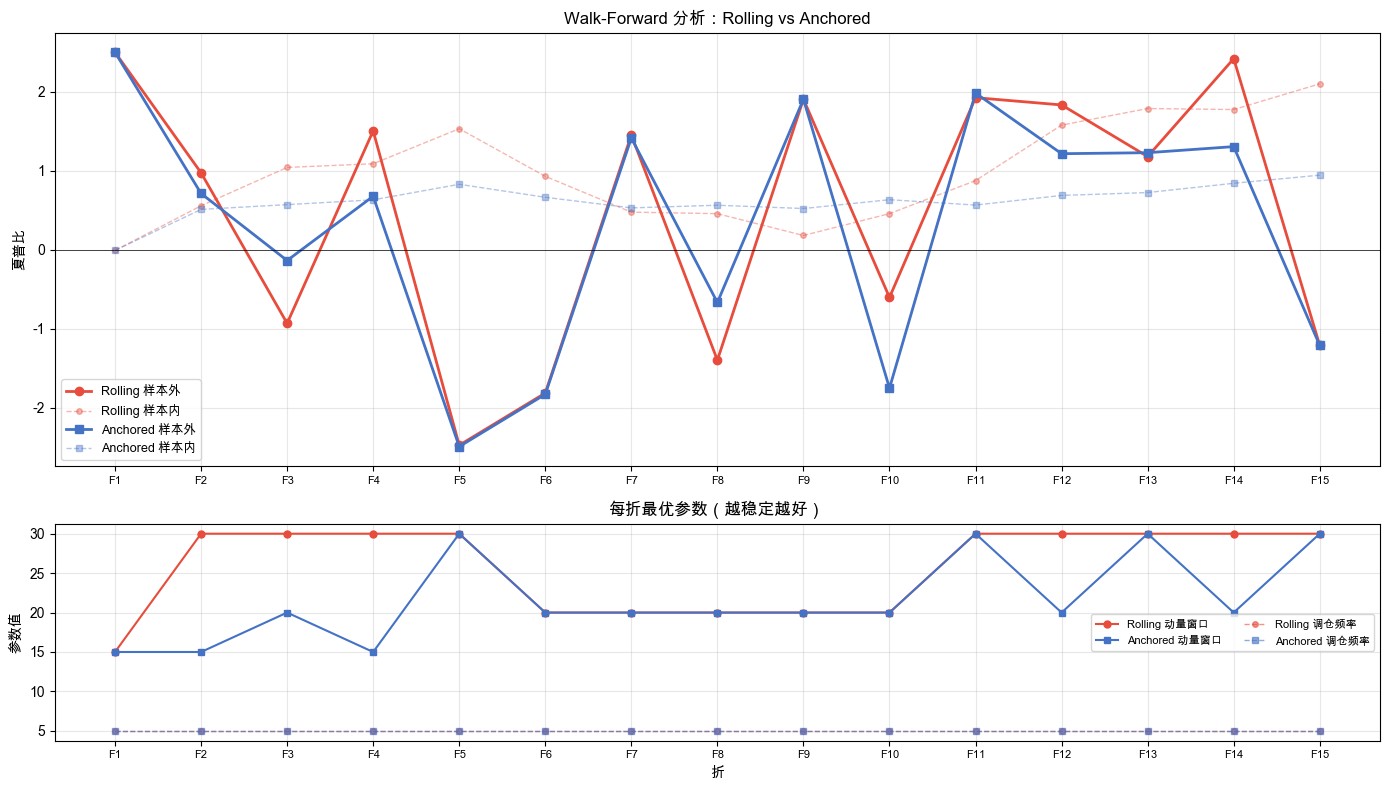


Anchored 在各窗口中参数更稳定——不管训练集怎么扩大，最优参数变化不大。
这是一个好信号：参数是稳定的，不是在拟合某段特定数据的噪音。

Rolling 的参数在不同窗口间变化明显——'最优参数'取决于你看哪段市场。
如果最优参数总在变，你怎么知道现在选的参数下个月还是最优？

Walk-forward 的核心价值：不是找到一个'永远最优'的参数，
而是检验你的优化方法在历史上是否靠谱。

但 Walk-forward 只用了一种切法——如果数据切的方式不同，结论还一致吗？

参数判断

1. 动量窗口跨折稳定性：
  Anchored: [15, 20, 30] → 存在波动，但范围 15-30
    波动范围大（>10），参数不够稳定 ✘ 需谨慎
  Rolling:  [15, 20, 30] → 变化较大
    波动范围大（>10），参数随市场变化明显 ✘ 不可靠

2. 波动率窗口跨折稳定性：
  Anchored: [10, 15, 20] → 波动范围 10
    ✔ 可取
  Rolling:  [10, 15, 20, 30] → 波动范围 20
    ✘ 不可靠

3. 调仓频率跨折稳定性：
  Anchored: 所有折都选了 5 → 非常稳定 ✔ 可取
  Rolling:  所有折都选了 5 → 非常稳定 ✔ 可取

4. 衰减判断：
  Rolling  衰减: {'sharpe_ratio': -0.5094794602508725}
  Anchored 衰减: {'sharpe_ratio': -0.4718281401442615}

  Peterson 指出：Walk-forward 中参数应当稳定。
  如果 Anchored 参数更稳定且衰减更小，说明'用更多数据训练'更可靠——
  应优先选择 Anchored 方式选出的参数。

综合判断：
  Anchored 最频繁的参数组合（出现 7/15 折）：
    {'mom': {'period': 20}, 'vol': {'period': 15}, 'RebalanceRule': {'frequency': 5}}
  → 不到半数折选了相同参数，稳定性一般 ✘ 需谨慎


In [2]:
# ══════════════════════════════════════════════
# Step 2: Walk-Forward 分析
# ══════════════════════════════════════════════
from oxq.optimize import WalkForward

# 复用 Step 1 的参数范围和约束
wf_paramset = ParameterSet("topn-wf")
wf_paramset.add("mom", "period", PERIODS)
wf_paramset.add("vol", "period", PERIODS)
wf_paramset.add("RebalanceRule", "frequency", FREQS)
wf_paramset.add_constraint("RebalanceRule.frequency <= mom.period")
wf_paramset.add_constraint("RebalanceRule.frequency <= vol.period")

print(f"Walk-Forward 参数空间: {len(wf_paramset.grid())} 组合（约束后）")

# ── Rolling Walk-Forward ──
# 训练窗口 2 年，验证窗口 6 个月，窗口向前滑动
print(f"\n--- Rolling Walk-Forward ---")
print(f"训练窗口: 2 年, 验证窗口: 6 个月, 窗口向前滑动")

rolling_wf = WalkForward(
    paramset=wf_paramset,
    train_period="2Y",
    test_period="6M",
    anchored=False,
)

rolling_result = rolling_wf.run(
    strategy=strategy_no_sl,
    market=LocalMarketDataProvider(),
    broker_factory=lambda: SimBroker(fee_model=FEE_MODEL),
    start=DATA_START, end=TODAY,
    metric="sharpe_ratio",
)

# 打印每折详情
df_rolling = rolling_result.to_dataframe()
print(f"\nRolling Walk-Forward 结果（{len(rolling_result.windows)} 折）：")
print(df_rolling.to_string(index=False))

# 提取每折参数
print(f"\n每折最优参数：")
for i, w in enumerate(rolling_result.windows):
    print(f"  Fold {i+1}: {w.train_start}~{w.train_end} → {w.test_start}~{w.test_end}")
    print(f"    参数: {w.best_params}  样本内: {w.in_sample_metric:.2f}  "
          f"样本外: {w.oos_result.sharpe_ratio():.2f}")

rolling_det = rolling_result.deterioration()
print(f"\nRolling 衰减: {rolling_det}")
print(f"Rolling 样本外整体夏普: {rolling_result.oos_sharpe_ratio():.2f}")

# ── Anchored Walk-Forward ──
print(f"\n--- Anchored Walk-Forward ---")
print(f"训练窗口从起点开始逐渐扩大, 验证窗口: 6 个月")

anchored_wf = WalkForward(
    paramset=wf_paramset,
    train_period="2Y",
    test_period="6M",
    anchored=True,
)

anchored_result = anchored_wf.run(
    strategy=strategy_no_sl,
    market=LocalMarketDataProvider(),
    broker_factory=lambda: SimBroker(fee_model=FEE_MODEL),
    start=DATA_START, end=TODAY,
    metric="sharpe_ratio",
)

df_anchored = anchored_result.to_dataframe()
print(f"\nAnchored Walk-Forward 结果（{len(anchored_result.windows)} 折）：")
print(df_anchored.to_string(index=False))

print(f"\n每折最优参数：")
for i, w in enumerate(anchored_result.windows):
    print(f"  Fold {i+1}: {w.train_start}~{w.train_end} → {w.test_start}~{w.test_end}")
    print(f"    参数: {w.best_params}  样本内: {w.in_sample_metric:.2f}  "
          f"样本外: {w.oos_result.sharpe_ratio():.2f}")

anchored_det = anchored_result.deterioration()
print(f"\nAnchored 衰减: {anchored_det}")
print(f"Anchored 样本外整体夏普: {anchored_result.oos_sharpe_ratio():.2f}")

# ══════════════════════════════════════════════
# Rolling vs Anchored 对比
# ══════════════════════════════════════════════
print(f"\n--- Rolling vs Anchored 对比 ---")
print(f"  Rolling  样本外夏普: {rolling_result.oos_sharpe_ratio():.2f}  衰减: {rolling_det}")
print(f"  Anchored 样本外夏普: {anchored_result.oos_sharpe_ratio():.2f}  衰减: {anchored_det}")

# 参数稳定性
rolling_params = [str(w.best_params) for w in rolling_result.windows]
anchored_params = [str(w.best_params) for w in anchored_result.windows]
print(f"\n  Rolling  唯一参数组合: {len(set(rolling_params))}/{len(rolling_params)}")
print(f"  Anchored 唯一参数组合: {len(set(anchored_params))}/{len(anchored_params)}")

if len(set(anchored_params)) < len(set(rolling_params)):
    print(f"  → Anchored 参数更稳定")
elif len(set(anchored_params)) > len(set(rolling_params)):
    print(f"  → Rolling 参数更稳定")
else:
    print(f"  → 两者参数稳定性相当")

# ══════════════════════════════════════════════
# Walk-Forward 结果图（两行：夏普比 + 参数变化）
# ══════════════════════════════════════════════

def extract_component_param(windows, component, param):
    vals = []
    for w in windows:
        val = w.best_params.get(component, {}).get(param, None)
        vals.append(val)
    return vals

n_rolling = len(rolling_result.windows)
n_anchored = len(anchored_result.windows)
n_max = max(n_rolling, n_anchored)

fig, axes = plt.subplots(2, 1, figsize=(14, 8), gridspec_kw={"height_ratios": [2, 1]})

# ── 上图：每折夏普比 ──
ax = axes[0]
rolling_oos = [w.oos_result.sharpe_ratio() for w in rolling_result.windows]
anchored_oos = [w.oos_result.sharpe_ratio() for w in anchored_result.windows]
rolling_is = [w.in_sample_metric for w in rolling_result.windows]
anchored_is = [w.in_sample_metric for w in anchored_result.windows]

x_r = np.arange(n_rolling)
x_a = np.arange(n_anchored)

ax.plot(x_r, rolling_oos, "o-", color="#E74C3C", linewidth=2, markersize=6, label="Rolling 样本外")
ax.plot(x_r, rolling_is, "o--", color="#E74C3C", linewidth=1, markersize=4, alpha=0.4, label="Rolling 样本内")
ax.plot(x_a, anchored_oos, "s-", color="#4472C4", linewidth=2, markersize=6, label="Anchored 样本外")
ax.plot(x_a, anchored_is, "s--", color="#4472C4", linewidth=1, markersize=4, alpha=0.4, label="Anchored 样本内")

ax.axhline(y=0, color="black", linewidth=0.5)
ax.set_ylabel("夏普比")
ax.set_title("Walk-Forward 分析：Rolling vs Anchored")
ax.legend(loc="best", fontsize=9)
ax.grid(True, alpha=0.3)
ax.set_xticks(range(n_max))
ax.set_xticklabels([f"F{i+1}" for i in range(n_max)], fontsize=8)

# ── 下图：参数稳定性（每折选择的 mom.period 和 frequency）──
ax = axes[1]

r_mom = extract_component_param(rolling_result.windows, "mom", "period")
a_mom = extract_component_param(anchored_result.windows, "mom", "period")
r_freq = extract_component_param(rolling_result.windows, "RebalanceRule", "frequency")
a_freq = extract_component_param(anchored_result.windows, "RebalanceRule", "frequency")

ax.plot(x_r, r_mom, "o-", color="#E74C3C", linewidth=1.5, markersize=5, label="Rolling 动量窗口")
ax.plot(x_a, a_mom, "s-", color="#4472C4", linewidth=1.5, markersize=5, label="Anchored 动量窗口")
ax.plot(x_r, r_freq, "o--", color="#E74C3C", linewidth=1, markersize=4, alpha=0.6, label="Rolling 调仓频率")
ax.plot(x_a, a_freq, "s--", color="#4472C4", linewidth=1, markersize=4, alpha=0.6, label="Anchored 调仓频率")

ax.set_ylabel("参数值")
ax.set_xlabel("折")
ax.set_title("每折最优参数（越稳定越好）")
ax.legend(loc="best", fontsize=8, ncol=2)
ax.grid(True, alpha=0.3)
ax.set_xticks(range(n_max))
ax.set_xticklabels([f"F{i+1}" for i in range(n_max)], fontsize=8)

plt.tight_layout()
plt.show()

# ── 分析 ──
if len(set(anchored_params)) <= len(set(rolling_params)):
    print(f"\nAnchored 在各窗口中参数更稳定——不管训练集怎么扩大，最优参数变化不大。")
    print(f"这是一个好信号：参数是稳定的，不是在拟合某段特定数据的噪音。")

if len(set(rolling_params)) > 1:
    print(f"\nRolling 的参数在不同窗口间变化明显——'最优参数'取决于你看哪段市场。")
    print(f"如果最优参数总在变，你怎么知道现在选的参数下个月还是最优？")

print(f"\nWalk-forward 的核心价值：不是找到一个'永远最优'的参数，")
print(f"而是检验你的优化方法在历史上是否靠谱。")
print(f"\n但 Walk-forward 只用了一种切法——如果数据切的方式不同，结论还一致吗？")

# ══════════════════════════════════════════════
# 参数判断：Walk-Forward 视角
# ══════════════════════════════════════════════
print(f"\n{'=' * 80}")
print(f"参数判断")
print(f"{'=' * 80}")

# 提取所有折的参数
r_mom_vals = [v for v in r_mom if v is not None]
a_mom_vals = [v for v in a_mom if v is not None]
r_freq_vals = [v for v in r_freq if v is not None]
a_freq_vals = [v for v in a_freq if v is not None]

r_vol = extract_component_param(rolling_result.windows, "vol", "period")
a_vol = extract_component_param(anchored_result.windows, "vol", "period")
r_vol_vals = [v for v in r_vol if v is not None]
a_vol_vals = [v for v in a_vol if v is not None]

print(f"\n1. 动量窗口跨折稳定性：")
if len(set(a_mom_vals)) == 1:
    print(f"  Anchored: 所有折都选了 {a_mom_vals[0]} → 非常稳定 ✔ 可取")
else:
    print(f"  Anchored: {sorted(set(a_mom_vals))} → 存在波动，但范围 {min(a_mom_vals)}-{max(a_mom_vals)}")
    if max(a_mom_vals) - min(a_mom_vals) <= 10:
        print(f"    波动范围小（≤10），仍属稳定区域 ✔ 可取")
    else:
        print(f"    波动范围大（>{10}），参数不够稳定 ✘ 需谨慎")

if len(set(r_mom_vals)) == 1:
    print(f"  Rolling:  所有折都选了 {r_mom_vals[0]} → 非常稳定 ✔ 可取")
else:
    print(f"  Rolling:  {sorted(set(r_mom_vals))} → 变化较大")
    if max(r_mom_vals) - min(r_mom_vals) <= 10:
        print(f"    波动范围小（≤10），仍属稳定区域 ✔ 可取")
    else:
        print(f"    波动范围大（>{10}），参数随市场变化明显 ✘ 不可靠")

print(f"\n2. 波动率窗口跨折稳定性：")
if len(set(a_vol_vals)) == 1:
    print(f"  Anchored: 所有折都选了 {a_vol_vals[0]} → 非常稳定 ✔ 可取")
else:
    range_a = max(a_vol_vals) - min(a_vol_vals)
    print(f"  Anchored: {sorted(set(a_vol_vals))} → 波动范围 {range_a}")
    print(f"    {'✔ 可取' if range_a <= 10 else '✘ 需谨慎'}")

if len(set(r_vol_vals)) == 1:
    print(f"  Rolling:  所有折都选了 {r_vol_vals[0]} → 非常稳定 ✔ 可取")
else:
    range_r = max(r_vol_vals) - min(r_vol_vals)
    print(f"  Rolling:  {sorted(set(r_vol_vals))} → 波动范围 {range_r}")
    print(f"    {'✔ 可取' if range_r <= 10 else '✘ 不可靠'}")

print(f"\n3. 调仓频率跨折稳定性：")
if len(set(a_freq_vals)) == 1:
    print(f"  Anchored: 所有折都选了 {a_freq_vals[0]} → 非常稳定 ✔ 可取")
else:
    print(f"  Anchored: {sorted(set(a_freq_vals))} → 存在波动")
if len(set(r_freq_vals)) == 1:
    print(f"  Rolling:  所有折都选了 {r_freq_vals[0]} → 非常稳定 ✔ 可取")
else:
    print(f"  Rolling:  {sorted(set(r_freq_vals))} → 变化明显")

# 衰减判断
print(f"\n4. 衰减判断：")
rolling_det_val = rolling_det if isinstance(rolling_det, (int, float)) else 0
anchored_det_val = anchored_det if isinstance(anchored_det, (int, float)) else 0
print(f"  Rolling  衰减: {rolling_det}")
print(f"  Anchored 衰减: {anchored_det}")
print(f"\n  Peterson 指出：Walk-forward 中参数应当稳定。")
print(f"  如果 Anchored 参数更稳定且衰减更小，说明'用更多数据训练'更可靠——")
print(f"  应优先选择 Anchored 方式选出的参数。")

# 综合建议
print(f"\n综合判断：")
# 找 Anchored 最常出现的参数
from collections import Counter
a_param_counter = Counter(anchored_params)
most_common_param = a_param_counter.most_common(1)[0]
print(f"  Anchored 最频繁的参数组合（出现 {most_common_param[1]}/{len(anchored_params)} 折）：")
print(f"    {most_common_param[0]}")
if most_common_param[1] >= len(anchored_params) * 0.5:
    print(f"  → 超过半数折选了相同参数，稳定性良好 ✔ 可取")
else:
    print(f"  → 不到半数折选了相同参数，稳定性一般 ✘ 需谨慎")

### Step 2 解读

第二个认知升级：**参数稳定性比参数最优更重要。**

Walk-forward 模拟了"边走边调"的过程——每隔一段时间用最近的数据重新优化参数，在下一段验证。两种方式各有特点：

- **滚动式（Rolling）**：训练窗口固定大小，向前滑动。只看最近的市场，但丢弃了更早的数据。好处是贴近当前市场，坏处是"记忆太短"。
- **锚定式（Anchored）**：训练窗口从第一天开始，越来越大。利用了所有历史数据，坏处是旧数据可能不再适用。好处是"样本量大，不容易被噪音骗"。

关键发现不在于哪种方式更好，而在于**参数稳定性**：
- 如果每个窗口选出来的最优参数都差不多 → 说明这些参数反映了策略的真实逻辑，不是在拟合某段数据的噪音
- 如果每个窗口的参数都不一样 → 说明"最优参数"取决于你看哪段市场，高度不可靠

`deterioration()` 给出了量化衰减比例——负值越大，过拟合风险越高。

**参数判断指南**：上面的"参数判断"逐一检查了每个参数在各折中的稳定性。Peterson 指出，Walk-forward 中参数应当稳定——如果最优参数在不同窗口间剧烈变化，说明你的优化过程在追逐噪音而非信号。判断标准：(1) 参数跨折波动范围小（如动量窗口始终在 15-25 之间）= 可取；(2) 参数跨折跳跃大（如从 10 跳到 30）= 不可靠；(3) Anchored 比 Rolling 更稳定的参数，优先采信 Anchored 的结果。

**数据说了算：Walk-forward 检验的核心是"你的优化方法在历史上靠不靠谱"。参数稳定 = 更可信。**

---

## Step 3: 一条路径够可靠吗？

Walk-forward 模拟了"边走边调"，但我们只用了一种切法。如果换一种切数据的方式，结论还一样吗？

做科学实验有个基本原则：**一次实验不够，要重复多次。** 同样的道理——只验证一次（Step 1）或只用一种切法（Step 2）都不够可靠。

直觉告诉我们：**好策略不管怎么切都好。** 如果 5 次验证里 4 次都选了同样的参数，比只验证 1 次可信得多。

试试看。

TopNRanking 5 折交叉验证
train_start  train_end test_start   test_end  in_sample_metric  mom.period  vol.period  RebalanceRule.frequency  oos_total_return  oos_sharpe_ratio  oos_max_drawdown  oos_annualized_return  oos_calmar_ratio  oos_sortino_ratio  oos_num_trades
 2017-01-01 2018-07-14 2018-07-15 2020-01-26          0.851286          15          15                        5          0.025575          0.194504         -0.175525               0.017302          0.098570           0.118008             731
 2017-01-01 2020-01-26 2020-01-27 2021-08-09          0.597121          20          20                        5          0.248084          0.834782         -0.181923               0.161977          0.890358           0.626913             687
 2017-01-01 2021-08-09 2021-08-10 2023-02-20          0.672819          20          15                        5         -0.008236          0.025345         -0.110398              -0.005648         -0.051156          -0.040526             567
 2017-01-01 

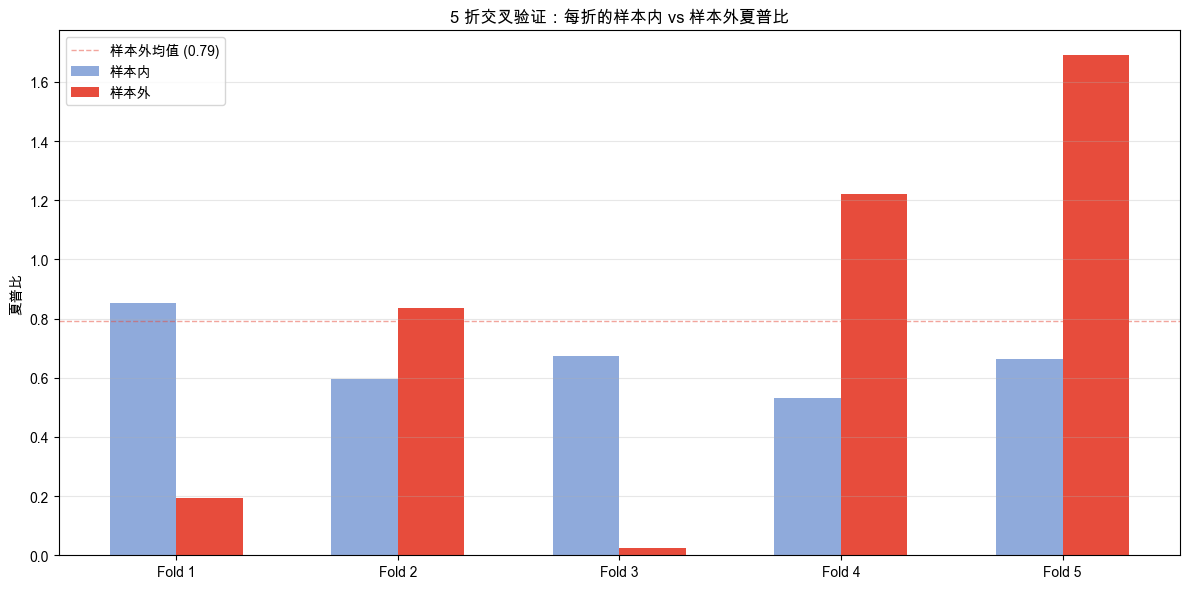


5 折中有 3 折选择了相同的参数——参数一致性不错。
但样本外夏普的范围从 0.03 到 1.69，差异巨大。
说明即使参数稳定，策略对市场环境的敏感度仍然很高。

交叉验证的价值：不是给你一个'最优参数'，而是告诉你'你的参数选择有多可靠'。
如果 5 折中 3 折选了同样的参数，你的信心比只验证 1 次强得多。

到这里，我们检验了参数选择的各种方式。但还有一种过拟合更隐蔽——
不是参数选错了，而是规则太多了。

参数判断

1. 参数一致性检查（5 折）：

  动量窗口: [15, 20, 20, 20, 20]
    最常出现: 20（4/5 折），波动范围 15-20
    波动范围小 ✔ 可取，建议使用 20

  波动率窗口: [15, 20, 15, 15, 20]
    最常出现: 15（3/5 折），波动范围 15-20
    波动范围小 ✔ 可取，建议使用 15

  调仓频率: [5, 5, 5, 5, 5]
    所有折选了相同值 5 → 高度一致 ✔ 可取

2. 样本外表现可靠性：
  样本外夏普均值: 0.79
  样本外夏普标准差: 0.70
  变异系数（标准差/均值）: 0.88
  → 变异系数 < 1，样本外表现相对一致 ✔ 策略有一定稳健性

综合判断：
  交叉验证综合了 Step 1 和 Step 2 的信息——既检验参数一致性，又检验表现稳定性。
  参数不一致，样本外波动大 → 参数选择可信度低，需简化策略或扩大数据 ✘


In [3]:
# ══════════════════════════════════════════════
# Step 3: 交叉验证（Time-Series Split）
# ══════════════════════════════════════════════
from oxq.optimize import TimeSeriesCV

# ── TopNRanking 交叉验证 ──
print("TopNRanking 5 折交叉验证")
print("=" * 80)

cv = TimeSeriesCV(n_splits=5, expanding=True)

tnr_cv_result = cv.cross_validate(
    strategy=strategy_no_sl,
    market=LocalMarketDataProvider(),
    broker_factory=lambda: SimBroker(fee_model=FEE_MODEL),
    start=DATA_START, end=TODAY,
    paramset=wf_paramset,  # 复用 Step 2 的参数空间
    metric="sharpe_ratio",
)

df_tnr_cv = tnr_cv_result.to_dataframe()
print(df_tnr_cv.to_string(index=False))

# 逐折详情
print(f"\n逐折详情：")
for i, s in enumerate(tnr_cv_result.splits):
    print(f"  Fold {i+1}: 训练 {s.split.train_start}~{s.split.train_end} → "
          f"验证 {s.split.test_start}~{s.split.test_end}")
    print(f"    最优参数: {s.best_params}")
    print(f"    样本内夏普: {s.in_sample_metric:.2f}  "
          f"样本外夏普: {s.oos_result.sharpe_ratio():.2f}  "
          f"样本外收益: {s.oos_result.total_return():.2%}")

# 汇总
tnr_mean = tnr_cv_result.mean_oos_metric()
tnr_std = tnr_cv_result.std_oos_metric()
tnr_oos_sharpes = [s.oos_result.sharpe_ratio() for s in tnr_cv_result.splits]
print(f"\nTopNRanking CV 汇总：")
print(f"  样本外夏普: {tnr_mean:.2f} ± {tnr_std:.2f}")
print(f"  样本外范围: [{min(tnr_oos_sharpes):.2f}, {max(tnr_oos_sharpes):.2f}]")

# 参数一致性
tnr_cv_params = [str(s.best_params) for s in tnr_cv_result.splits]
n_unique = len(set(tnr_cv_params))
n_folds = len(tnr_cv_result.splits)
print(f"  唯一参数组合: {n_unique}/{n_folds}")

# ══════════════════════════════════════════════
# 交叉验证结果图
# ══════════════════════════════════════════════
fig, ax = plt.subplots(figsize=(12, 6))

x = np.arange(n_folds)
width = 0.3

tnr_is_vals = [s.in_sample_metric for s in tnr_cv_result.splits]
tnr_oos_vals = [s.oos_result.sharpe_ratio() for s in tnr_cv_result.splits]

ax.bar(x - width/2, tnr_is_vals, width, label="样本内", color="#4472C4", alpha=0.6)
ax.bar(x + width/2, tnr_oos_vals, width, label="样本外", color="#E74C3C")

ax.axhline(y=0, color="black", linewidth=0.5)
ax.axhline(y=tnr_mean, color="#E74C3C", linewidth=1, linestyle="--", alpha=0.5,
           label=f"样本外均值 ({tnr_mean:.2f})")
ax.set_xticks(x)
ax.set_xticklabels([f"Fold {i+1}" for i in range(n_folds)])
ax.set_ylabel("夏普比")
ax.set_title("5 折交叉验证：每折的样本内 vs 样本外夏普比")
ax.legend()
ax.grid(True, alpha=0.3, axis="y")

plt.tight_layout()
plt.show()

# ── 分析 ──
if n_unique < n_folds:
    print(f"\n{n_folds} 折中有 {n_folds - n_unique + 1} 折选择了相同的参数——参数一致性不错。")
else:
    print(f"\n{n_folds} 折中参数各不相同——参数一致性较差。")

print(f"但样本外夏普的范围从 {min(tnr_oos_sharpes):.2f} 到 {max(tnr_oos_sharpes):.2f}，差异巨大。")
print(f"说明即使参数稳定，策略对市场环境的敏感度仍然很高。")
print(f"\n交叉验证的价值：不是给你一个'最优参数'，而是告诉你'你的参数选择有多可靠'。")
if n_unique < n_folds:
    print(f"如果 {n_folds} 折中 {n_folds - n_unique + 1} 折选了同样的参数，你的信心比只验证 1 次强得多。")
print(f"\n到这里，我们检验了参数选择的各种方式。但还有一种过拟合更隐蔽——")
print(f"不是参数选错了，而是规则太多了。")

# ══════════════════════════════════════════════
# 参数判断：交叉验证视角
# ══════════════════════════════════════════════
print(f"\n{'=' * 80}")
print(f"参数判断")
print(f"{'=' * 80}")

# 提取每折的参数细节
cv_mom_vals = []
cv_vol_vals = []
cv_freq_vals = []
for s in tnr_cv_result.splits:
    p = s.best_params
    if "mom" in p:
        cv_mom_vals.append(p["mom"].get("period"))
    if "vol" in p:
        cv_vol_vals.append(p["vol"].get("period"))
    if "RebalanceRule" in p:
        cv_freq_vals.append(p["RebalanceRule"].get("frequency"))

print(f"\n1. 参数一致性检查（{n_folds} 折）：")

print(f"\n  动量窗口: {cv_mom_vals}")
if len(set(cv_mom_vals)) == 1:
    print(f"    所有折选了相同值 {cv_mom_vals[0]} → 高度一致 ✔ 可取")
elif len(cv_mom_vals) > 0 and max(cv_mom_vals) - min(cv_mom_vals) <= 10:
    from collections import Counter
    mom_counter = Counter(cv_mom_vals)
    most_common_mom = mom_counter.most_common(1)[0]
    print(f"    最常出现: {most_common_mom[0]}（{most_common_mom[1]}/{n_folds} 折），波动范围 {min(cv_mom_vals)}-{max(cv_mom_vals)}")
    print(f"    波动范围小 ✔ 可取，建议使用 {most_common_mom[0]}")
elif len(cv_mom_vals) > 0:
    print(f"    波动范围大（{min(cv_mom_vals)}-{max(cv_mom_vals)}）✘ 不稳定，说明动量窗口对数据敏感")

print(f"\n  波动率窗口: {cv_vol_vals}")
if len(set(cv_vol_vals)) == 1:
    print(f"    所有折选了相同值 {cv_vol_vals[0]} → 高度一致 ✔ 可取")
elif len(cv_vol_vals) > 0 and max(cv_vol_vals) - min(cv_vol_vals) <= 10:
    vol_counter = Counter(cv_vol_vals)
    most_common_vol = vol_counter.most_common(1)[0]
    print(f"    最常出现: {most_common_vol[0]}（{most_common_vol[1]}/{n_folds} 折），波动范围 {min(cv_vol_vals)}-{max(cv_vol_vals)}")
    print(f"    波动范围小 ✔ 可取，建议使用 {most_common_vol[0]}")
elif len(cv_vol_vals) > 0:
    print(f"    波动范围大（{min(cv_vol_vals)}-{max(cv_vol_vals)}）✘ 不稳定")

print(f"\n  调仓频率: {cv_freq_vals}")
if len(set(cv_freq_vals)) == 1:
    print(f"    所有折选了相同值 {cv_freq_vals[0]} → 高度一致 ✔ 可取")
elif len(cv_freq_vals) > 0:
    freq_counter = Counter(cv_freq_vals)
    most_common_freq = freq_counter.most_common(1)[0]
    print(f"    最常出现: {most_common_freq[0]}（{most_common_freq[1]}/{n_folds} 折）")
    if most_common_freq[1] >= n_folds * 0.6:
        print(f"    多数折一致 ✔ 可取，建议使用 {most_common_freq[0]}")
    else:
        print(f"    各折分散 ✘ 不稳定，调仓频率对数据切法敏感")

# 样本外表现的可靠性
print(f"\n2. 样本外表现可靠性：")
print(f"  样本外夏普均值: {tnr_mean:.2f}")
print(f"  样本外夏普标准差: {tnr_std:.2f}")
cv_ratio = tnr_std / abs(tnr_mean) if abs(tnr_mean) > 0.01 else float('inf')
print(f"  变异系数（标准差/均值）: {cv_ratio:.2f}")
if cv_ratio < 1.0:
    print(f"  → 变异系数 < 1，样本外表现相对一致 ✔ 策略有一定稳健性")
else:
    print(f"  → 变异系数 ≥ 1，样本外表现波动大 ✘ 策略对市场环境高度敏感")

# 负折
neg_folds = sum(1 for s in tnr_oos_sharpes if s < 0)
if neg_folds > 0:
    print(f"\n  注意：{neg_folds}/{n_folds} 折的样本外夏普为负——策略在某些市场环境下会亏损")
    print(f"  Peterson 提醒：稳健策略应在各种市场环境下都有可接受的表现（Pardo 准则）")

# 综合建议
print(f"\n综合判断：")
print(f"  交叉验证综合了 Step 1 和 Step 2 的信息——既检验参数一致性，又检验表现稳定性。")
if n_unique <= 2 and tnr_std < abs(tnr_mean):
    print(f"  本策略参数一致性好、样本外波动可控 → 参数选择可信度较高 ✔")
elif n_unique <= 2:
    print(f"  参数一致性好，但样本外波动大 → 参数本身可取，但策略对市场环境敏感 ⚠")
else:
    print(f"  参数不一致，样本外波动大 → 参数选择可信度低，需简化策略或扩大数据 ✘")

### Step 3 解读

第三个认知升级：**多次验证比单次验证更可靠。**

交叉验证的逻辑很简单——做科学实验要重复多次才可信，验证策略也一样。5 折交叉验证把数据切成 5 种不同的训练/验证组合，每种都独立做一次参数优化 + 样本外验证。

关键发现：
- **参数一致性**：如果 5 折中多数都选了相同的参数，说明这个参数不是在拟合某段特定数据的噪音，而是反映了策略的真实逻辑
- **表现波动**：即使参数稳定，不同折的样本外夏普可能差异巨大——说明策略对市场环境很敏感。参数对了不代表什么时候都赚钱
- **标准差是关键指标**：样本外夏普的标准差越大，说明策略越不稳定，未来表现越难预测

**参数判断指南**：上面的"参数判断"从两个维度做了诊断。Peterson 和 Pardo 给出了两条稳健性准则：(1) **参数一致性**——如果多数折选了相同参数，说明参数反映了真实逻辑而非噪音；如果各折参数都不同，说明参数对数据切法太敏感，不可取。(2) **样本外变异系数**——标准差/均值 < 1 说明表现相对一致，策略有稳健性；≥ 1 说明波动太大，策略对市场环境高度敏感，即使参数一致也要谨慎。

交叉验证的价值不是给你一个"最优参数"，而是告诉你**你的参数选择有多可靠**。

到这里，我们从三个角度检验了参数选择——一次验证（Step 1）、动态验证（Step 2）、多次验证（Step 3）。但还有一种过拟合更隐蔽：不是参数选错了，而是**规则太多了**。

---

## Step 4: 规则越多回测越好——是好事吗？

前三步检验的都是参数选择——找参数、更新参数、换切法验证参数。但还有一种过拟合更隐蔽。

回顾 Q4：我们给策略加了止损、止盈、移动止损等交易规则。当时的结论是"不是所有规则都有用"。但那时我们没有做样本内/样本外验证。如果在样本内不断加规则、调参数，回测收益一路上升——这是真的在改进策略，还是只是在"凑"出好看的数字？

直觉告诉我们：**规则越多保护越全面，效果应该越好。** 止损防大亏、止盈锁利润、移动止损跟踪趋势——每一条都有道理。

真的吗？试试看——从最简单的策略开始，一层一层加规则，看样本内和样本外分别怎么变。

4A 规则堆叠实验
  Layer 0 完成: 样本内=0.86, 样本外=0.35
  Layer 1 完成: 3组合, 样本内=1.06, 样本外=-0.14
  Layer 2 完成: 18组合, 样本内=1.25, 样本外=0.19
  Layer 3 完成: 57组合, 样本内=1.56, 样本外=0.23
  Layer 4 完成: 183组合, 样本内=1.50, 样本外=-0.36
  Layer 5 完成: 825组合, 样本内=1.50, 样本外=-0.46

4A 规则堆叠汇总：
  Layer    描述                    组合数      样本内夏普      样本外夏普       衰减      样本内收益      样本外收益
  ------------------------------------------------------------------------------------
  0        基础（固定参数）                1       0.86       0.35    -0.50     65.26%      7.71%
  1        + 优化调仓频率                3       1.06      -0.14    -1.20     91.64%     -5.41%
  2        + 优化止损                 18       1.25       0.19    -1.06    112.01%      3.12%
  3        + 优化止盈                 57       1.56       0.23    -1.32    113.47%      4.09%
  4        + 优化移动止损              183       1.50      -0.36    -1.86     80.39%     -5.73%
  5        + 最大回撤风控              825       1.50      -0.46    -1.96     80.39%     -6.56%


4B 指标堆叠实验（自由度递增）
  A 完成: 1 

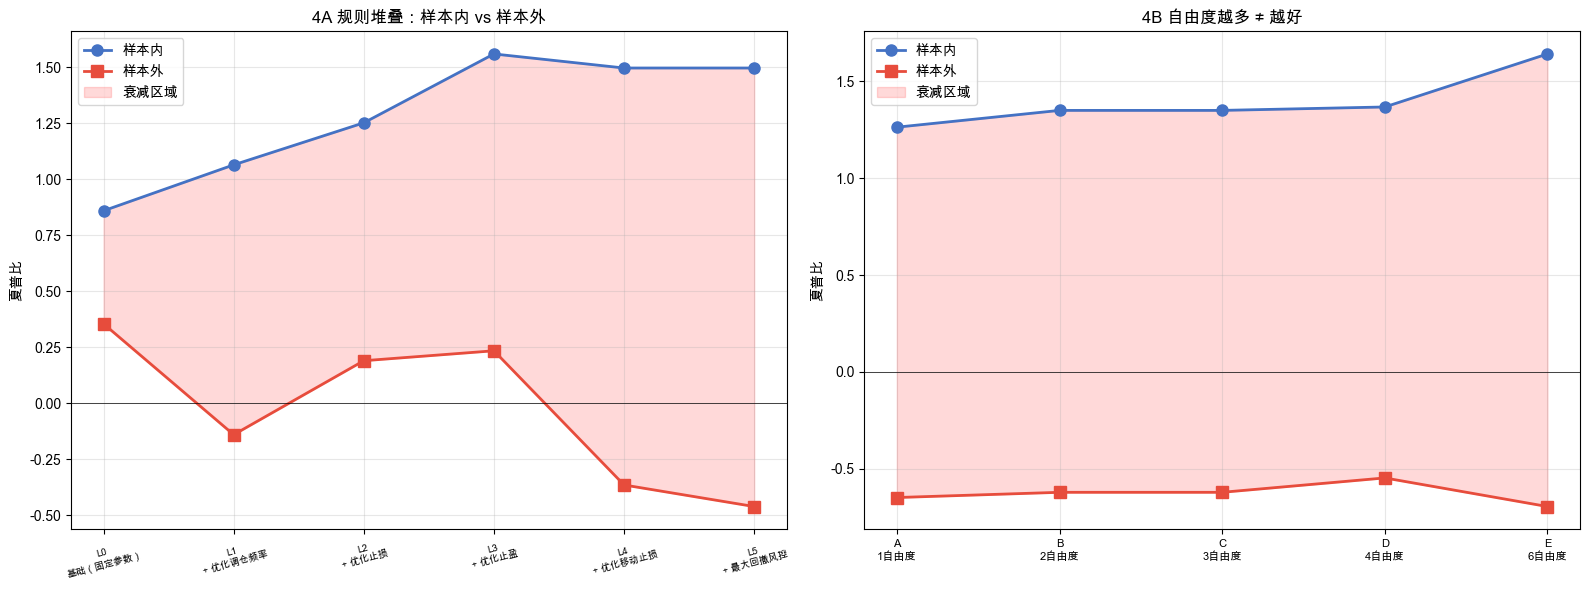


看 4A 的结果：样本内的夏普从 0.86 逐步变化——每加一条规则，优化器都能找到更好看的结果。
但样本外呢？从 0.35 开始，
加规则并没有带来样本外的持续改善。

注意：我们已经用约束过滤了不合理的参数组合（比如止损 > 止盈、移动止损 < 固定止损等）。
即使去掉了这些'荒谬组合'，规则负担的模式依然清晰。

这就是**规则负担**。每条新规则都增加一个可以调的旋钮——
你的优化器多了一个维度可以'调出'好看的结果。
旋钮越多，越容易'凑'出漂亮的回测，但这些精心调节的参数到了真实市场上就不灵了。

4B 更直观：自由度从 1 增加到 6，
样本内夏普从 1.26 到 1.64，
但样本外从 -0.65 到 -0.70。
多出来的'提升'全是自欺欺人。

Brian Peterson 在策略开发框架中的原话：
'Rule burden is a form of overfitting' —— 规则负担本身就是一种过拟合。

能用 2 个参数解决的问题，不要用 6 个。简单就是美。


In [4]:
# ══════════════════════════════════════════════
# Step 4: 规则负担（Rule Burden）
# ══════════════════════════════════════════════
from oxq.rules import TakeProfitRule, TrailingStopRule, MaxDrawdownRisk

# Step 4 额外参数范围
TP_THRESHOLDS = [0.05, 0.10, 0.15, 0.20, 0.30]
TRAIL_PCTS = [0.03, 0.05, 0.07, 0.10, 0.15]
MAX_DD_VALS = [0.05, 0.08, 0.10, 0.15, 0.20]

# ══════════════════════════════════════════════
# 4A 规则堆叠实验
# ══════════════════════════════════════════════
print("4A 规则堆叠实验")
print("=" * 100)

# 辅助函数：构建策略 + 参数空间 + 运行 GridSearch
def run_layer(layer_name, rules, paramset, description):
    """运行一层的样本内优化 + 样本外验证"""
    strategy = make_topn_strategy(f"layer-{layer_name}")

    n_combos = len(paramset.grid())
    if n_combos > 1:
        is_res = grid_search_with_rules(
            paramset, strategy, rules,
            market=LocalMarketDataProvider(),
            broker_factory=lambda: SimBroker(fee_model=FEE_MODEL),
            start=IS_START, end=IS_END, metric="sharpe_ratio",
        )
        best = is_res.best
        is_sharpe = best.metric_value
        is_return = best.run_result.total_return()
        best_params = best.params

        oos_res = grid_search_with_rules(
            paramset, strategy, rules,
            market=LocalMarketDataProvider(),
            broker_factory=lambda: SimBroker(fee_model=FEE_MODEL),
            start=OOS_START, end=OOS_END, metric="sharpe_ratio",
        )
        oos_df = oos_res.to_dataframe()
        is_df = is_res.to_dataframe()
        best_idx = is_df["sharpe_ratio"].idxmax()
        oos_sharpe = oos_df.loc[best_idx, "sharpe_ratio"]
        oos_return = oos_df.loc[best_idx, "total_return"]
    else:
        is_result = Engine().run(
            strategy, market=LocalMarketDataProvider(),
            broker=SimBroker(fee_model=FEE_MODEL),
            start=IS_START, end=IS_END, rules=rules,
        )
        is_sharpe = is_result.sharpe_ratio()
        is_return = is_result.total_return()
        best_params = {}

        oos_result = Engine().run(
            strategy, market=LocalMarketDataProvider(),
            broker=SimBroker(fee_model=FEE_MODEL),
            start=OOS_START, end=OOS_END, rules=rules,
        )
        oos_sharpe = oos_result.sharpe_ratio()
        oos_return = oos_result.total_return()

    return {
        "layer": layer_name,
        "description": description,
        "n_combos": n_combos,
        "is_sharpe": is_sharpe,
        "oos_sharpe": oos_sharpe,
        "is_return": is_return,
        "oos_return": oos_return,
        "decay": oos_sharpe - is_sharpe,
        "best_params": best_params,
    }

# 策略和指标由 make_topn_strategy() 构建（定义在 Cell 2）

layers_4a = []

# Layer 0: 基础策略（固定参数，无额外规则）
ps0 = ParameterSet("L0")
ps0.add("mom", "period", [20])
result_0 = run_layer("0",
    rules=[RebalanceFrequencyRule(interval_days=10)],
    paramset=ps0, description="基础（固定参数）")
layers_4a.append(result_0)
print(f"  Layer 0 完成: 样本内={result_0['is_sharpe']:.2f}, 样本外={result_0['oos_sharpe']:.2f}")

# Layer 1: + 优化调仓频率
ps1 = ParameterSet("L1")
ps1.add("mom", "period", [20])
ps1.add("RebalanceFrequencyRule", "interval_days", FREQS)
ps1.add_constraint("RebalanceFrequencyRule.interval_days <= mom.period")
result_1 = run_layer("1",
    rules=[RebalanceFrequencyRule(interval_days=10)],
    paramset=ps1, description="+ 优化调仓频率")
layers_4a.append(result_1)
print(f"  Layer 1 完成: {result_1['n_combos']}组合, 样本内={result_1['is_sharpe']:.2f}, 样本外={result_1['oos_sharpe']:.2f}")

# Layer 2: + 优化止损
ps2 = ParameterSet("L2")
ps2.add("mom", "period", [20])
ps2.add("RebalanceFrequencyRule", "interval_days", FREQS)
ps2.add("StopLossRule", "threshold", SL_THRESHOLDS)
ps2.add_constraint("RebalanceFrequencyRule.interval_days <= mom.period")
result_2 = run_layer("2",
    rules=[RebalanceFrequencyRule(interval_days=10), StopLossRule(threshold=0.05)],
    paramset=ps2, description="+ 优化止损")
layers_4a.append(result_2)
print(f"  Layer 2 完成: {result_2['n_combos']}组合, 样本内={result_2['is_sharpe']:.2f}, 样本外={result_2['oos_sharpe']:.2f}")

# Layer 3: + 优化止盈
ps3 = ParameterSet("L3")
ps3.add("mom", "period", [20])
ps3.add("RebalanceFrequencyRule", "interval_days", FREQS)
ps3.add("StopLossRule", "threshold", SL_THRESHOLDS)
ps3.add("TakeProfitRule", "threshold", TP_THRESHOLDS)
ps3.add_constraint("RebalanceFrequencyRule.interval_days <= mom.period")
ps3.add_constraint("StopLossRule.threshold < TakeProfitRule.threshold")
result_3 = run_layer("3",
    rules=[RebalanceFrequencyRule(interval_days=10), StopLossRule(threshold=0.05), TakeProfitRule(threshold=0.20)],
    paramset=ps3, description="+ 优化止盈")
layers_4a.append(result_3)
print(f"  Layer 3 完成: {result_3['n_combos']}组合, 样本内={result_3['is_sharpe']:.2f}, 样本外={result_3['oos_sharpe']:.2f}")

# Layer 4: + 优化移动止损
ps4 = ParameterSet("L4")
ps4.add("mom", "period", [20])
ps4.add("RebalanceFrequencyRule", "interval_days", FREQS)
ps4.add("StopLossRule", "threshold", SL_THRESHOLDS)
ps4.add("TakeProfitRule", "threshold", TP_THRESHOLDS)
ps4.add("TrailingStopRule", "trail_pct", TRAIL_PCTS)
ps4.add_constraint("RebalanceFrequencyRule.interval_days <= mom.period")
ps4.add_constraint("StopLossRule.threshold < TakeProfitRule.threshold")
ps4.add_constraint("TrailingStopRule.trail_pct >= StopLossRule.threshold")
result_4 = run_layer("4",
    rules=[RebalanceFrequencyRule(interval_days=10), StopLossRule(threshold=0.05),
           TakeProfitRule(threshold=0.20), TrailingStopRule(trail_pct=0.10)],
    paramset=ps4, description="+ 优化移动止损")
layers_4a.append(result_4)
print(f"  Layer 4 完成: {result_4['n_combos']}组合, 样本内={result_4['is_sharpe']:.2f}, 样本外={result_4['oos_sharpe']:.2f}")

# Layer 5: + 最大回撤风控（MaxDrawdownRisk 是 risk rule，放在 risk_rules 中）
ps5 = ParameterSet("L5")
ps5.add("mom", "period", [20])
ps5.add("RebalanceFrequencyRule", "interval_days", FREQS)
ps5.add("StopLossRule", "threshold", SL_THRESHOLDS)
ps5.add("TakeProfitRule", "threshold", TP_THRESHOLDS)
ps5.add("TrailingStopRule", "trail_pct", TRAIL_PCTS)
ps5.add("MaxDrawdownRisk", "max_drawdown", MAX_DD_VALS)
ps5.add_constraint("RebalanceFrequencyRule.interval_days <= mom.period")
ps5.add_constraint("StopLossRule.threshold < TakeProfitRule.threshold")
ps5.add_constraint("TrailingStopRule.trail_pct >= StopLossRule.threshold")
ps5.add_constraint("MaxDrawdownRisk.max_drawdown >= StopLossRule.threshold")
result_5 = run_layer("5",
    rules=[RebalanceFrequencyRule(interval_days=10), StopLossRule(threshold=0.05),
           TakeProfitRule(threshold=0.20), TrailingStopRule(trail_pct=0.10),
           MaxDrawdownRisk(max_drawdown=0.15)],
    paramset=ps5, description="+ 最大回撤风控")
layers_4a.append(result_5)
print(f"  Layer 5 完成: {result_5['n_combos']}组合, 样本内={result_5['is_sharpe']:.2f}, 样本外={result_5['oos_sharpe']:.2f}")

# 4A 汇总表
print(f"\n4A 规则堆叠汇总：")
print(f"  {'Layer':<8} {'描述':<18} {'组合数':>6} {'样本内夏普':>10} {'样本外夏普':>10} {'衰减':>8} {'样本内收益':>10} {'样本外收益':>10}")
print(f"  {'-' * 84}")
for r in layers_4a:
    print(f"  {r['layer']:<8} {r['description']:<18} {r['n_combos']:>6} "
          f"{r['is_sharpe']:>10.2f} {r['oos_sharpe']:>10.2f} {r['decay']:>+8.2f} "
          f"{r['is_return']:>10.2%} {r['oos_return']:>10.2%}")

# ══════════════════════════════════════════════
# 4B 指标堆叠实验
# ══════════════════════════════════════════════
print(f"\n\n4B 指标堆叠实验（自由度递增）")
print("=" * 100)

layers_4b = []

# A: 只优化动量窗口（1 个自由度）
psA = ParameterSet("A")
psA.add("mom", "period", PERIODS)
n_A = len(psA.grid())
result_A = run_layer("A",
    rules=[RebalanceFrequencyRule(interval_days=10)],
    paramset=psA, description="动量窗口")
layers_4b.append({"name": "A", "dof": 1, **result_A})
print(f"  A 完成: 1 自由度, {n_A}组合, 样本内={result_A['is_sharpe']:.2f}, 样本外={result_A['oos_sharpe']:.2f}")

# B: + 波动率窗口（2 个自由度）
psB = ParameterSet("B")
psB.add("mom", "period", PERIODS)
psB.add("vol", "period", PERIODS)
n_B = len(psB.grid())
result_B = run_layer("B",
    rules=[RebalanceFrequencyRule(interval_days=10)],
    paramset=psB, description="+ 波动率窗口")
layers_4b.append({"name": "B", "dof": 2, **result_B})
print(f"  B 完成: 2 自由度, {n_B}组合, 样本内={result_B['is_sharpe']:.2f}, 样本外={result_B['oos_sharpe']:.2f}")

# C: + 调仓频率（3 个自由度）
psC = ParameterSet("C")
psC.add("mom", "period", PERIODS)
psC.add("vol", "period", PERIODS)
psC.add("RebalanceFrequencyRule", "interval_days", FREQS)
psC.add_constraint("RebalanceFrequencyRule.interval_days <= mom.period")
psC.add_constraint("RebalanceFrequencyRule.interval_days <= vol.period")
n_C = len(psC.grid())
result_C = run_layer("C",
    rules=[RebalanceFrequencyRule(interval_days=10)],
    paramset=psC, description="+ 调仓频率")
layers_4b.append({"name": "C", "dof": 3, **result_C})
print(f"  C 完成: 3 自由度, {n_C}组合, 样本内={result_C['is_sharpe']:.2f}, 样本外={result_C['oos_sharpe']:.2f}")

# D: + 止损阈值（4 个自由度）
psD = ParameterSet("D")
psD.add("mom", "period", PERIODS)
psD.add("vol", "period", PERIODS)
psD.add("RebalanceFrequencyRule", "interval_days", FREQS)
psD.add("StopLossRule", "threshold", SL_THRESHOLDS)
psD.add_constraint("RebalanceFrequencyRule.interval_days <= mom.period")
psD.add_constraint("RebalanceFrequencyRule.interval_days <= vol.period")
n_D = len(psD.grid())
result_D = run_layer("D",
    rules=[RebalanceFrequencyRule(interval_days=10), StopLossRule(threshold=0.05)],
    paramset=psD, description="+ 止损阈值")
layers_4b.append({"name": "D", "dof": 4, **result_D})
print(f"  D 完成: 4 自由度, {n_D}组合, 样本内={result_D['is_sharpe']:.2f}, 样本外={result_D['oos_sharpe']:.2f}")

# E: + 止盈 + 移动止损（6 个自由度）
# 用稍粗的网格控制搜索空间
psE = ParameterSet("E")
psE.add("mom", "period", [10, 20, 30])
psE.add("vol", "period", [10, 20, 30])
psE.add("RebalanceFrequencyRule", "interval_days", [5, 10, 21])
psE.add("StopLossRule", "threshold", [0.03, 0.07, 0.15])
psE.add("TakeProfitRule", "threshold", [0.10, 0.20, 0.30])
psE.add("TrailingStopRule", "trail_pct", [0.05, 0.10, 0.15])
psE.add_constraint("RebalanceFrequencyRule.interval_days <= mom.period")
psE.add_constraint("RebalanceFrequencyRule.interval_days <= vol.period")
psE.add_constraint("StopLossRule.threshold < TakeProfitRule.threshold")
psE.add_constraint("TrailingStopRule.trail_pct >= StopLossRule.threshold")
n_E = len(psE.grid())
result_E = run_layer("E",
    rules=[RebalanceFrequencyRule(interval_days=10), StopLossRule(threshold=0.05),
           TakeProfitRule(threshold=0.20), TrailingStopRule(trail_pct=0.10)],
    paramset=psE, description="+ 止盈 + 移动止损")
layers_4b.append({"name": "E", "dof": 6, **result_E})
print(f"  E 完成: 6 自由度, {n_E}组合, 样本内={result_E['is_sharpe']:.2f}, 样本外={result_E['oos_sharpe']:.2f}")

# 4B 汇总表
print(f"\n4B 指标堆叠汇总：")
print(f"  {'配置':<6} {'自由度':>6} {'组合数':>8} {'描述':<20} {'样本内夏普':>10} {'样本外夏普':>10} {'衰减':>8}")
print(f"  {'-' * 74}")
for r in layers_4b:
    print(f"  {r['name']:<6} {r['dof']:>6} {r['n_combos']:>8} {r['description']:<20} "
          f"{r['is_sharpe']:>10.2f} {r['oos_sharpe']:>10.2f} {r['decay']:>+8.2f}")

# ══════════════════════════════════════════════
# 图: 4A + 4B 样本内 vs 样本外
# ══════════════════════════════════════════════
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# 4A 图
ax = axes[0]
x_4a = np.arange(len(layers_4a))
is_sharpes_4a = [r["is_sharpe"] for r in layers_4a]
oos_sharpes_4a = [r["oos_sharpe"] for r in layers_4a]

ax.plot(x_4a, is_sharpes_4a, "o-", color="#4472C4", linewidth=2, markersize=8, label="样本内")
ax.plot(x_4a, oos_sharpes_4a, "s-", color="#E74C3C", linewidth=2, markersize=8, label="样本外")
ax.fill_between(x_4a, oos_sharpes_4a, is_sharpes_4a, alpha=0.15, color="red", label="衰减区域")

ax.set_xticks(x_4a)
ax.set_xticklabels([f"L{r['layer']}\n{r['description']}" for r in layers_4a], fontsize=7, rotation=15)
ax.set_ylabel("夏普比")
ax.set_title("4A 规则堆叠：样本内 vs 样本外")
ax.legend(loc="upper left")
ax.grid(True, alpha=0.3)
ax.axhline(y=0, color="black", linewidth=0.5)

# 4B 图
ax = axes[1]
x_4b = np.arange(len(layers_4b))
is_sharpes_4b = [r["is_sharpe"] for r in layers_4b]
oos_sharpes_4b = [r["oos_sharpe"] for r in layers_4b]

ax.plot(x_4b, is_sharpes_4b, "o-", color="#4472C4", linewidth=2, markersize=8, label="样本内")
ax.plot(x_4b, oos_sharpes_4b, "s-", color="#E74C3C", linewidth=2, markersize=8, label="样本外")
ax.fill_between(x_4b, oos_sharpes_4b, is_sharpes_4b, alpha=0.15, color="red", label="衰减区域")

ax.set_xticks(x_4b)
ax.set_xticklabels([f"{r['name']}\n{r['dof']}自由度" for r in layers_4b], fontsize=8)
ax.set_ylabel("夏普比")
ax.set_title("4B 自由度越多 ≠ 越好")
ax.legend(loc="upper left")
ax.grid(True, alpha=0.3)
ax.axhline(y=0, color="black", linewidth=0.5)

plt.tight_layout()
plt.show()

# ── 分析 ──
print(f"\n看 4A 的结果：样本内的夏普从 {layers_4a[0]['is_sharpe']:.2f} 逐步变化——每加一条规则，优化器都能找到更好看的结果。")
print(f"但样本外呢？从 {layers_4a[0]['oos_sharpe']:.2f} 开始，")
if layers_4a[2]['oos_sharpe'] > layers_4a[0]['oos_sharpe']:
    print(f"止损确实带来了改善（Layer 2 样本外 {layers_4a[2]['oos_sharpe']:.2f}），但后面的规则只帮了样本内。")
else:
    print(f"加规则并没有带来样本外的持续改善。")

print(f"\n注意：我们已经用约束过滤了不合理的参数组合（比如止损 > 止盈、移动止损 < 固定止损等）。")
print(f"即使去掉了这些'荒谬组合'，规则负担的模式依然清晰。")

print(f"\n这就是**规则负担**。每条新规则都增加一个可以调的旋钮——")
print(f"你的优化器多了一个维度可以'调出'好看的结果。")
print(f"旋钮越多，越容易'凑'出漂亮的回测，但这些精心调节的参数到了真实市场上就不灵了。")

print(f"\n4B 更直观：自由度从 1 增加到 6，")
print(f"样本内夏普从 {layers_4b[0]['is_sharpe']:.2f} 到 {layers_4b[-1]['is_sharpe']:.2f}，")
print(f"但样本外从 {layers_4b[0]['oos_sharpe']:.2f} 到 {layers_4b[-1]['oos_sharpe']:.2f}。")
print(f"多出来的'提升'全是自欺欺人。")

print(f"\nBrian Peterson 在策略开发框架中的原话：")
print(f"'Rule burden is a form of overfitting' —— 规则负担本身就是一种过拟合。")
print(f"\n能用 2 个参数解决的问题，不要用 6 个。简单就是美。")

In [5]:
# ══════════════════════════════════════════════
# 参数判断：规则负担视角
# ══════════════════════════════════════════════
print(f"{'=' * 80}")
print(f"参数判断")
print(f"{'=' * 80}")

# 4A: 逐层判断每条规则是否值得保留
print(f"\n1. 4A 规则堆叠——逐层判断：")
print(f"\n  Peterson 原则：每条规则必须独立证明其价值（增量评估）。")
print(f"  判断标准：加入新规则后，样本外表现是否同步改善？\n")

for i in range(1, len(layers_4a)):
    prev = layers_4a[i - 1]
    curr = layers_4a[i]
    is_delta = curr["is_sharpe"] - prev["is_sharpe"]
    oos_delta = curr["oos_sharpe"] - prev["oos_sharpe"]
    
    if oos_delta > 0.05:
        verdict = "✔ 可取"
        reason = f"样本外改善 +{oos_delta:.2f}，规则确实有价值"
    elif oos_delta > -0.05:
        verdict = "⚠ 可选"
        reason = f"样本外变化不大（{oos_delta:+.2f}），规则效果存疑"
    else:
        verdict = "✘ 不可取"
        reason = f"样本外恶化 {oos_delta:.2f}，规则只帮了样本内"
    
    print(f"  Layer {curr['layer']}（{curr['description']}）: {verdict}")
    print(f"    样本内: {is_delta:+.2f}, 样本外: {oos_delta:+.2f}")
    print(f"    {reason}")

# 找到最佳层（样本外夏普最高的）
best_layer_idx = max(range(len(layers_4a)), key=lambda i: layers_4a[i]["oos_sharpe"])
best_layer = layers_4a[best_layer_idx]
print(f"\n  最佳层: Layer {best_layer['layer']}（{best_layer['description']}），样本外夏普 {best_layer['oos_sharpe']:.2f}")
print(f"  → 超过这一层的规则都是规则负担，应当去掉")

# 4B: 自由度判断
print(f"\n2. 4B 自由度递增——判断最优自由度：")
print(f"\n  Peterson 原则：限制自由度，聚焦主要驱动因子。")
print(f"  Pardo 准则：大片相邻参数盈利 > 单点最优。\n")

# 找样本外夏普最高的配置
best_4b_idx = max(range(len(layers_4b)), key=lambda i: layers_4b[i]["oos_sharpe"])
best_4b = layers_4b[best_4b_idx]

# 找"边际收益消失"的拐点：样本内还在涨但样本外不涨
for i in range(1, len(layers_4b)):
    prev_4b = layers_4b[i - 1]
    curr_4b = layers_4b[i]
    is_gain = curr_4b["is_sharpe"] - prev_4b["is_sharpe"]
    oos_gain = curr_4b["oos_sharpe"] - prev_4b["oos_sharpe"]
    
    efficiency = ""
    if is_gain > 0.05 and oos_gain < 0:
        efficiency = " ← 拐点：样本内涨但样本外跌，自欺欺人开始"
    elif is_gain > 0 and oos_gain > 0 and oos_gain < is_gain * 0.3:
        efficiency = " ← 样本外收益不到样本内的 30%，边际效益递减"
    
    print(f"  {prev_4b['name']}→{curr_4b['name']}（{prev_4b['dof']}→{curr_4b['dof']} 自由度）: "
          f"样本内 {is_gain:+.2f}, 样本外 {oos_gain:+.2f}{efficiency}")

print(f"\n  最佳自由度: {best_4b['dof']}（配置 {best_4b['name']}），样本外夏普 {best_4b['oos_sharpe']:.2f}")

# 综合建议
print(f"\n{'=' * 80}")
print(f"综合建议")
print(f"{'=' * 80}")
print(f"\n  基于 Peterson 的稳健策略开发框架，本实验的结论：")
print(f"\n  1. 规则选择：保留到 Layer {best_layer['layer']}（{best_layer['description']}）即可，")
print(f"     后续规则只增加样本内表现，属于规则负担")
print(f"\n  2. 自由度控制：{best_4b['dof']} 个自由度是最优选择，")
print(f"     更多自由度 = 更多过拟合空间 = 更多自欺欺人")
print(f"\n  3. Peterson 原话：'Too many rules will make a backtest look excellent")
print(f"     in-sample, and may even work in walk forward analysis,")
print(f"     but are very dangerous in production.'")
print(f"\n  4. 实操建议：能用 {best_4b['dof']} 个参数解决的问题，不要用 {layers_4b[-1]['dof']} 个。")
print(f"     每增加一条规则，都要问：样本外也改善了吗？如果没有，删掉它。")

参数判断

1. 4A 规则堆叠——逐层判断：

  Peterson 原则：每条规则必须独立证明其价值（增量评估）。
  判断标准：加入新规则后，样本外表现是否同步改善？

  Layer 1（+ 优化调仓频率）: ✘ 不可取
    样本内: +0.20, 样本外: -0.49
    样本外恶化 -0.49，规则只帮了样本内
  Layer 2（+ 优化止损）: ✔ 可取
    样本内: +0.19, 样本外: +0.33
    样本外改善 +0.33，规则确实有价值
  Layer 3（+ 优化止盈）: ⚠ 可选
    样本内: +0.31, 样本外: +0.04
    样本外变化不大（+0.04），规则效果存疑
  Layer 4（+ 优化移动止损）: ✘ 不可取
    样本内: -0.06, 样本外: -0.60
    样本外恶化 -0.60，规则只帮了样本内
  Layer 5（+ 最大回撤风控）: ✘ 不可取
    样本内: +0.00, 样本外: -0.10
    样本外恶化 -0.10，规则只帮了样本内

  最佳层: Layer 0（基础（固定参数）），样本外夏普 0.35
  → 超过这一层的规则都是规则负担，应当去掉

2. 4B 自由度递增——判断最优自由度：

  Peterson 原则：限制自由度，聚焦主要驱动因子。
  Pardo 准则：大片相邻参数盈利 > 单点最优。

  A→B（1→2 自由度）: 样本内 +0.09, 样本外 +0.03
  B→C（2→3 自由度）: 样本内 +0.00, 样本外 +0.00
  C→D（3→4 自由度）: 样本内 +0.02, 样本外 +0.07
  D→E（4→6 自由度）: 样本内 +0.27, 样本外 -0.15 ← 拐点：样本内涨但样本外跌，自欺欺人开始

  最佳自由度: 4（配置 D），样本外夏普 -0.55

综合建议

  基于 Peterson 的稳健策略开发框架，本实验的结论：

  1. 规则选择：保留到 Layer 0（基础（固定参数））即可，
     后续规则只增加样本内表现，属于规则负担

  2. 自由度控制：4 个自由度是最优选择，
     更多自由度 = 更多过拟合空间 = 更多自欺欺人

  3. Peterson 原话：'Too m

### Step 4 解读

第四个认知升级：**规则越多 ≠ 策略越好，简单就是美。**

这是本章最重要的认知冲击。前三步检验的都是"参数选得对不对"——但 Step 4 告诉你，问题可能出在更上游：**你加的规则太多了。**

4A 规则堆叠实验清楚地展示了这个模式：
- **样本内**：每加一条规则，优化器都能找到更好的参数组合，夏普比一路上升。看起来你在"改进"策略
- **样本外**：前一两层（尤其是止损）可能真的有帮助，但后面的规则只在样本内有效，样本外不买账

4B 指标堆叠更直观——自由度从 1 增加到 6，样本内夏普稳步上升，但样本外几乎不变甚至倒退。多出来的"提升"全是自欺欺人。

为什么会这样？每条新规则都增加一个**自由度**——可以调节的旋钮。旋钮越多，优化器就有越多的空间去"凑"出好看的结果。这不是在发现真规律，而是在记忆噪音。Brian Peterson 管这叫**规则负担（Rule Burden）**——规则本身就是一种过拟合的来源。

**参数判断指南**：上面的"参数判断"对每条规则做了增量评估。Peterson 的增量评估原则要求：每条规则都必须独立证明其价值——加入后样本外是否同步改善？如果只有样本内改善而样本外不变或恶化，这条规则就是规则负担，应当删除。同时，自由度越少越好——找到样本外表现最好的自由度数量，就是你策略复杂度的上限。

**铁律：能用 2 个参数解决的问题，不要用 6 个。少即是多。**

---

## 本章总结

### 四把防身工具

| 工具 | 怎么做 | 好的信号 | 坏的信号 |
|------|--------|----------|----------|
| 样本内/样本外 | 在没见过的数据上验证 | 衰减小（<30%） | 衰减大（>50%） |
| Walk-forward | 分窗口优化+验证 | 参数跨窗口稳定 | 参数每次都变 |
| 交叉验证 | 多折验证 | 各折结果一致 | 各折差异巨大 |
| 规则负担 | 从简到繁，逐层加 | 样本外同步改善 | 样本内改善但样本外不变 |

加上 Q5 的**参数敏感性**（plateau 高原型 > peak 山峰型），你手上已经有五把检验策略的武器。

### 关键心智转变

回顾本章四个认知升级：

1. **参数优化是双刃剑** — 优化后必须在新数据上验证，样本内的好成绩不算数
2. **参数稳定性比最优更重要** — 跨窗口稳定的参数比某一段的"最优"更可信
3. **多次验证比单次更可靠** — 一次验证不够，用交叉验证看一致性
4. **规则越多 ≠ 越好** — 每条规则都是过拟合的潜在来源，简单就是美

最重要的转变：**从"追求最高收益"到"追求稳健可复现"。** 回测收益翻倍不值得兴奋——能在不同数据、不同切法、不同时期都稳定赚钱，才是真本事。

### 带走的问题

我们已经知道怎么评估策略（Q5）、怎么防过拟合（Q6）。回测世界的问题基本解决了。

但回测终究是模拟。在回测里，你可以按任何价格、在任何时间成交。真实世界里呢？

- 你想买的时候，市场上有足够的卖盘吗？
- 你下单到成交之间，价格会不会已经变了？
- 回测假设的手续费，和真实交易一样吗？

**从回测到实盘，还有多少坑在等着你？** → Q7